# 📘 Tutorial 2: Geometry and Conditioning of Optimisation

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Tutorial 1**, we studied gradient descent as a **dynamical system**, focusing on how the update rule behaves over time.

In this tutorial, we shift attention to the **shape of the problem being optimised**.

Even when using the same optimisation algorithm, some problems converge quickly while others move slowly, oscillate across narrow valleys, or require careful tuning of the learning rate.

These differences are largely explained by the **geometry of the loss landscape**.

To make this idea concrete, we study simple quadratic objectives of the form

$$L(x) = \tfrac{1}{2} x^\top A x,$$

which provide a clean setting for visualising how curvature affects optimisation behaviour.

---

**This tutorial is designed to shift perspective**
- from *“gradient descent sometimes works and sometimes struggles”*
- to *“optimisation behaviour follows directly from the geometry of the objective.”*

---

**The emphasis is on developing intuition for**
- how uneven curvature creates narrow optimisation valleys,
- how the **condition number** measures optimisation difficulty,
- why gradient descent zig-zags in ill-conditioned landscapes,
- how scaling or reparameterisation can change optimisation behaviour,
- and why tuning learning rates often feels difficult in practice.

---

**Key ideas explored include**
- isotropic vs anisotropic quadratic objectives,
- the role of eigenvalues in shaping optimisation trajectories,
- the condition number as a measure of curvature imbalance,
- how conditioning affects convergence speed,
- and how simple parameter transformations can improve or worsen optimisation.

---

This tutorial builds directly on the dynamical perspective developed earlier and helps explain many common optimisation behaviours observed in practice, including:
- slow progress in narrow valleys,
- sensitivity to parameter scaling,
- and the importance of choosing a good representation of the problem.

These insights will prepare us for the next step: **modifying the optimisation algorithm itself to better handle difficult landscapes.**

---

**Recommended prerequisites**
- Completion of **Tutorial 1** in Part 2
- Basic understanding of gradient descent updates
- Familiarity with simple linear algebra concepts (eigenvalues and matrices)

---

**Author**: Angze Li

**Last updated**: 2026-04-14

**Version**: v2.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

set_seed(0)

## 1. Gradient Descent Package

In this tutorial we reuse the same helper functions introduced in **Tutorial 1**.

To keep the focus on conditioning and optimisation geometry, we do not repeat the full discussion here.

---

### What the code defines

**1. gd_step**
```python
def gd_step(x, grad, lr):
    return x - lr * grad
```
This implements a single **gradient descent update**

$$x_{t+1} = x_t - \eta \nabla f(x_t)$$

where:
- `grad` is the gradient $\nabla f(x_t)$
- `lr` is the learning rate $\eta$

**2. run_gd**

This function runs gradient descent for a fixed number of steps.

It:
- repeatedly evaluates the loss and gradient
- updates the parameters using `gd_step`
- records the optimisation trajectory and loss values

The function returns:
- `xs` – the full trajectory $\{x_t\}$
- `losses` – the loss value at each step

The decorator
```python
@torch.no_grad()
```
ensures PyTorch does not build **computation graphs**, since we are analysing optimisation dynamics rather than training a model.

**3. quad2d**

This defines a simple quadratic objective

$$L(x) = \tfrac12 x^\top A x$$

with gradient

$$\nabla L(x) = A x.$$

Quadratic functions are particularly useful for studying optimisation because:
- their geometry is easy to visualise,
- their curvature is fully determined by the matrix $A$,
- and many behaviours of gradient descent can be analysed exactly.

---

For a **more detailed explanation** of these helper functions, including the gradient descent dynamics and trajectory tracking, please refer back to **Tutorial 1**.

In [2]:
def gd_step(x, grad, lr):
    return x - lr * grad

@torch.no_grad()
def run_gd(x0, loss_grad_fn, lr, steps=60):
    x = x0.clone()
    xs, losses = [x.clone()], []

    for _ in range(steps):
        L, g = loss_grad_fn(x)
        losses.append(float(L))
        x = gd_step(x, g, lr)
        xs.append(x.clone())

    return torch.stack(xs), np.array(losses)

def quad2d(A):
    A = torch.tensor(A)

    def fn(x):
        L = 0.5 * x @ (A @ x)
        g = A @ x
        return L, g

    return fn

## 2. Constructing contour data for a quadratic loss surface

This helper function prepares the data needed to visualise the level sets (contours) of a 2-dimensional quadratic loss function

$$L(x) = \tfrac{1}{2} x^\top A x .$$

The resulting values are stored in $Z$, which represents the height of the loss surface at each point.

The outputs can then be passed to `matplotlib.contour()` to visualise the geometry of the loss landscape.

In [3]:
def contour_plot(A, xlim=(-3,3), ylim=(-3,3), levels=30):
    A = torch.tensor(A)

    x1 = np.linspace(*xlim, 200)
    x2 = np.linspace(*ylim, 200)
    X1, X2 = np.meshgrid(x1, x2)

    Z = np.zeros_like(X1)

    for i in range(X1.shape[0]):
        pts = torch.tensor(np.stack([X1[i], X2[i]], axis=-1))
        Z[i] = (0.5 * (pts * (pts @ A.T)).sum(dim=1)).numpy()

    return X1, X2, Z

## 3. Isotropic quadratic (easy optimisation)

We begin with the simplest possible quadratic objective:

$$L(x) = \tfrac{1}{2} x^\top A x,
\qquad
A =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}.$$

In this case, the matrix $A$ is the identity matrix, meaning the curvature is the **same in every direction**. Such problems are called **isotropic** or **well-conditioned**.

---

### What the code does
**1. Define the quadratic objective**

The matrix $A = I$ produces circular level sets for the loss function.
	
**2.Run gradient descent**

Starting from the initial point

$$x_0 = (2,2),$$

gradient descent is run for several steps using a fixed learning rate.

**3. Visualise the optimisation path**

The contour plot shows the level sets of the quadratic loss, and the sequence of iterates $\{x_t\}$ is overlaid on top.

---

### How to interpret the figure

Because curvature is identical in all directions:
- the contours are **perfect circles**
- the gradient **always points directly toward the minimum**
- the optimisation path follows a **straight line toward the origin**

As a result, gradient descent converges **smoothly and efficiently** without oscillations.

---

### Key insight

When the objective is well-conditioned (equal curvature in all directions), gradient descent behaves *almost* ideally: the gradient consistently points toward the minimum, and optimisation proceeds without the zig-zag behaviour seen in ill-conditioned problems.

In the next section, we will modify the matrix $A$ to introduce **anisotropic curvature**, revealing why optimisation can become significantly harder.

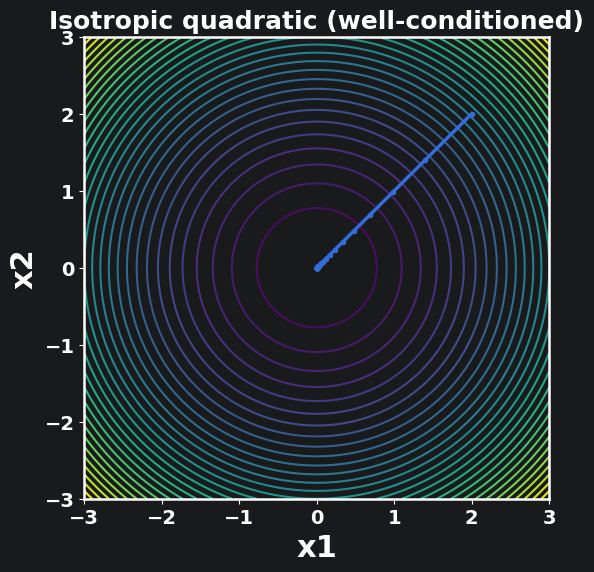

In [4]:
A = np.array([
    [1.0,0.0],
    [0.0,1.0]
])

f = quad2d(A)

x0 = torch.tensor([2.0,2.0])
xs, losses = run_gd(x0, f, lr=0.3, steps=40)

X1, X2, Z = contour_plot(A)

fig, ax = plt.subplots(figsize=(6,6))

ax.contour(X1, X2, Z, levels=30)

path = xs.numpy()
ax.plot(path[:,0], path[:,1], "-o", markersize=3, linewidth=2.5)

ax.set_title("Isotropic quadratic (well-conditioned)", fontsize=18, fontweight="bold")
ax.set_xlabel("x1", fontsize=22, fontweight="bold")
ax.set_ylabel("x2", fontsize=22, fontweight="bold")

style_ax(ax)
plt.show()

## 4. Ill-conditioned quadratic (narrow valley)

Next, we modify the quadratic objective so that the curvature **differs across directions**:

$$L(x) = \tfrac{1}{2} x^\top A x,
\qquad
A =
\begin{pmatrix}
10 & 0 \\
0 & 1
\end{pmatrix}.$$

Here, the curvature along the $x_1$ direction is ten times larger than along $x_2$.
This creates an **anisotropic loss landscape**, where the level sets are **elongated ellipses** rather than circles.

---

### What the code does
**1. Define an ill-conditioned quadratic**

The matrix $A$ introduces different curvature scales:
- steep curvature along $x_1$
- shallow curvature along $x_2$

**2. Run gradient descent**

Starting again from the point

$x_0 = (2,2),$

gradient descent is executed for several steps with a fixed learning rate.
	
**3. Overlay the optimisation trajectory**

The contour plot shows the elliptical level sets of the loss function, and the path of gradient descent is plotted on top.

---

### How to interpret the figure

Compared with the isotropic case:
- the contours are now **elongated ellipses**
- the gradient is dominated by the **steep direction** $x_1$
- gradient descent **repeatedly overshoots across the valley walls**

This produces the characteristic **zig-zag trajectory** often observed in ill-conditioned optimisation problems.

---

### Key insight

When curvature differs across directions, optimisation becomes harder:
- stability is determined by the **steepest direction**
- convergence speed is limited by the **flattest direction**

This mismatch forces gradient descent to take small steps to remain stable, leading to slow progress along the valley.

In the next section, we quantify this phenomenon using the **condition number**, which measures how strongly the objective is stretched across different directions.

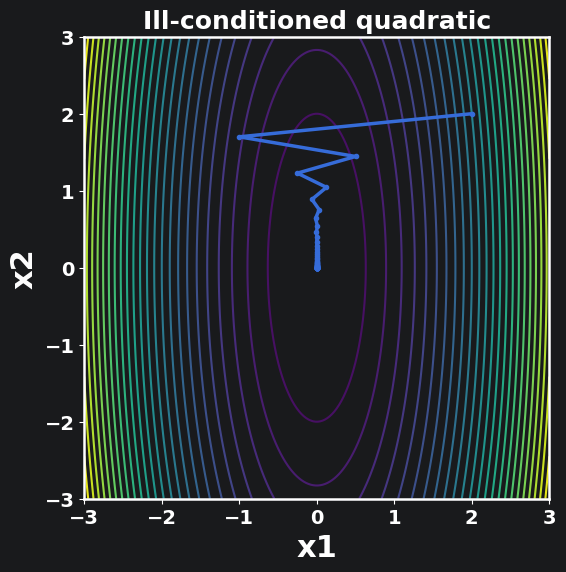

In [5]:
A = np.array([
    [10.0,0.0],
    [0.0,1.0]
])

f = quad2d(A)

x0 = torch.tensor([2.0,2.0])
xs, losses = run_gd(x0, f, lr=0.15, steps=60)

X1, X2, Z = contour_plot(A)

fig, ax = plt.subplots(figsize=(6,6))

ax.contour(X1, X2, Z, levels=30)

path = xs.numpy()
ax.plot(path[:,0], path[:,1], "-o", markersize=3, linewidth=2.5)

ax.set_title("Ill-conditioned quadratic", fontsize=18, fontweight="bold")
ax.set_xlabel("x1", fontsize=22, fontweight="bold")
ax.set_ylabel("x2", fontsize=22, fontweight="bold")

style_ax(ax)
plt.show()

## 5. Condition number

To **quantify** how stretched or anisotropic the quadratic objective is, we examine the eigenvalues of the matrix $A$.

For the quadratic loss

$$L(x) = \tfrac{1}{2} x^\top A x,$$

the eigenvalues of $A$ determine the **curvature of the loss surface along its principal directions**.

---

### What the code does
- `np.linalg.eigvals(A)` computes the eigenvalues of the matrix $A$.
- The **condition number**

$$\kappa = \frac{\lambda_{\text{max}}}{\lambda_{\text{min}}}$$

is then calculated as the ratio between the largest and smallest eigenvalues.

---

### Why this matters

The condition number measures how uneven the curvature of the objective is:
- Small $\kappa$ (close to 1)
  
    → curvature is similar in all directions
  
    → optimisation is easy
- Large $\kappa$
  
    → curvature differs strongly across directions
  
    → optimisation becomes difficult

In geometric terms, the condition number reflects how much the loss contours are **stretched into narrow ellipses**.

As $\kappa$ grows, gradient descent tends to produce the **zig-zag behaviour** observed in the previous figure.

In [6]:
eigvals = np.linalg.eigvals(A)
kappa = eigvals.max() / eigvals.min()

print("Eigenvalues:", eigvals)
print("Condition number:", kappa)

Eigenvalues: [10.  1.]
Condition number: 10.0


## 6. Conditioning vs convergence speed

In the previous section we introduced the condition number

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}},$$

which measures how uneven the curvature of a quadratic objective is.

We now explore how this quantity affects the **speed of optimisation**.

---

### What the code does

**1. Generate quadratic objectives with different conditioning**

The helper function

$$A =
\begin{pmatrix}
\kappa & 0 \\
0 & 1
\end{pmatrix}$$

creates quadratic problems with increasing condition numbers.

As $\kappa$ grows, the loss landscape becomes more **elongated and anisotropic**.

**2. Run gradient descent**

For each value of $\kappa$, gradient descent is run from the same starting point $x_0 = (2,2)$ using a fixed learning rate.

**3. Measure convergence speed**

We record the number of steps required for the loss to fall below a chosen tolerance:

$$L(x) < 10^{-3}.$$

**4. Plot the results**

The resulting plot shows how many iterations are needed to reach the same accuracy as the condition number increases.

---

### How to interpret the figure

For small condition numbers, gradient descent converges quickly.

However, as $\kappa$ increases, the optimisation behaviour changes dramatically. Beyond a certain point, the algorithm **fails to reach the target tolerance even after many iterations**.

This happens because the learning rate that worked for small $\kappa$ becomes **too large for the steep direction** when $\kappa$ grows.

Recall **Tutorial 1**: for a quadratic objective, gradient descent is stable only if

$$\eta < \frac{2}{\lambda_{\max}}.$$



Since $\lambda_{\max} = \kappa$ in this experiment, increasing $\kappa$ makes the stability bound increasingly restrictive. A learning rate that was safe before can therefore become unstable.

---

### Key insight

This experiment highlights two important facts about optimisation:
- **Conditioning strongly affects optimisation behaviour.**
- **A learning rate that works well for one problem may fail completely for another.**

In practice, this is why tuning learning rates can feel difficult: the appropriate step size depends directly on the **curvature structure of the objective**. Poor conditioning forces gradient descent to use smaller stable steps, slowing optimisation and making training more sensitive to hyperparameter choices.

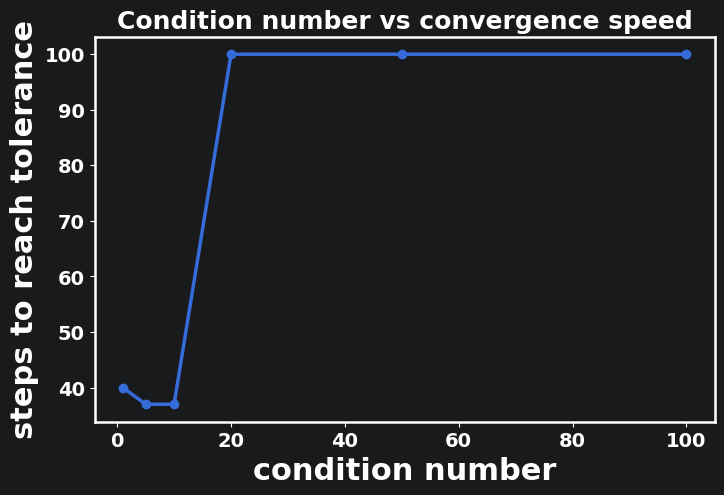

In [7]:
def make_matrix(kappa):
    return np.array([
        [kappa,0.0],
        [0.0,1.0]
    ])

x0 = torch.tensor([2.0,2.0])
lr = 1 / eigvals.max()

kappas = [1, 5, 10, 20, 50, 100]

steps_needed = []

for k in kappas:

    A = make_matrix(k)
    f = quad2d(A)

    xs, losses = run_gd(x0, f, lr=lr, steps=100)

    tol = 1e-3
    idx = np.argmax(losses < tol)

    if idx == 0:
        idx = len(losses)

    steps_needed.append(idx)

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(kappas, steps_needed, "-o", linewidth=2.5)

ax.set_title("Condition number vs convergence speed", fontsize=18, fontweight="bold")
ax.set_xlabel("condition number", fontsize=22, fontweight="bold")
ax.set_ylabel("steps to reach tolerance", fontsize=22, fontweight="bold")
style_ax(ax)

plt.show()

## 7. Scaling / reparameterisation

So far we have seen that optimisation difficulty depends strongly on the **curvature structure** of the objective. In particular, ill-conditioned problems arise when different directions in parameter space have very different curvature scales.

One way to understand this more deeply is through **reparameterisation**.

---

### Idea: change the coordinate system

Suppose we apply a linear change of variables

$$x = S z,$$

where $S$ is a scaling matrix. Substituting this into the quadratic objective

$$L(x) = \tfrac{1}{2} x^\top A x$$

gives

$$L(z) = \tfrac{1}{2} z^\top (S^\top A S) z .$$

This means that **changing the parameterisation modifies the effective curvature matrix**.

---

### What the code does
**1. A scaling matrix**

$$S =
\begin{pmatrix}
\text{scale} & 0 \\
0 & 1
\end{pmatrix}$$

is constructed.
	

**2. Matrix computation**

The transformed curvature matrix is computed as
$$A_{\text{new}} = S^\top A S.$$
	
**3. Curvature change**

The original and transformed matrices are printed to illustrate how the curvature changes under scaling.

---

### The role of the scaling parameter

The parameter scale controls how strongly the first coordinate is rescaled.
- **scale < 1**
  
    compresses the $x_1$ direction and reduces its curvature.
- **scale > 1**

    stretches the $x_1$ direction and increases its curvature.

In the example below, we use

$$\text{scale} = 0.3,$$

which reduces the curvature in the steep direction of the original matrix

$$A =
\begin{pmatrix}
10 & 0 \\
0 & 1
\end{pmatrix}.$$

This transformation makes the objective **less anisotropic**, effectively improving the conditioning of the problem.

---
### Why this matters

This simple experiment highlights an important fact:

> **Optimisation difficulty is not only a property of the objective itself, but also of how the parameters are represented.**

By rescaling coordinates appropriately, we can change the condition number of the problem and potentially make optimisation much easier.

This idea underlies many optimisation techniques, including **preconditioning, normalisation, and adaptive learning rate methods**, which attempt to compensate for differences in curvature across directions.

In [8]:
def transform_problem(A, scale):

    S = np.array([
        [scale,0],
        [0,1]
    ])

    A_new = S.T @ A @ S

    return A_new


A = np.array([
    [10.0,0.0],
    [0.0,1.0]
])

A_scaled = transform_problem(A, scale=0.3)

print("Original matrix:\n", A)
print("\nScaled matrix:\n", A_scaled)

Original matrix:
 [[10.  0.]
 [ 0.  1.]]

Scaled matrix:
 [[0.9 0. ]
 [0.  1. ]]


## 8. Compare optimisation before and after scaling

In the previous section we showed that a simple reparameterisation can change the curvature matrix from $A$ to

$$A_{\text{new}} = S^\top A S .$$

**Although the underlying objective function remains the same, the geometry of the optimisation problem changes.**

In this cell we visualise how this affects the behaviour of gradient descent.

---

### What the code does

**1. Run gradient descent on both problems**

We run gradient descent starting from the same initial point

$$x_0 = (2,2)$$

using the same learning rate and number of steps.

This ensures that any difference in behaviour comes purely from the geometry of the objective.

Two matrices are compared:
- the **original matrix** $A$ (ill-conditioned)
- the **scaled matrix** $A_{\text{scaled}}$ obtained through reparameterisation

---

**2. Plot the loss landscape**

For each matrix we compute the contour lines of the quadratic objective

$$L(x) = \tfrac{1}{2} x^\top A x .$$

These contours represent the **shape of the loss surface**.

---

3. Overlay the optimisation trajectory

The sequence of gradient descent iterates

$$x_{0}, x_{1}, x_{2}, \dots$$

is plotted on top of the contour lines.
This shows how the optimiser moves through the parameter space.

---

### How to interpret the figure

**Left panel — Original problem**
- The contours are **elongated ellipses**.
- Gradient descent repeatedly **zig-zags across the narrow valley**.
- Progress toward the minimum is slow because steps must remain stable in the steep direction.

**Right panel — Scaled problem**
- The contours become **almost circular**.
- Gradient descent moves **smoothly toward the minimum**.
- The optimisation path becomes much more direct.

---

### Condition number comparison

The condition numbers printed below the figure quantify this difference:

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}} .$$
- Large $\kappa$ → highly anisotropic curvature → difficult optimisation
- Small $\kappa$ → more balanced curvature → easier optimisation

In this example, the scaling transformation dramatically reduces the condition number, explaining the improved optimisation behaviour.

---

### Key insight

This experiment highlights an important principle:

> **Optimisation difficulty depends strongly on the geometry of the parameterisation.**

Even when the underlying objective function is unchanged, an appropriate scaling of the parameters can significantly improve the efficiency of gradient descent.

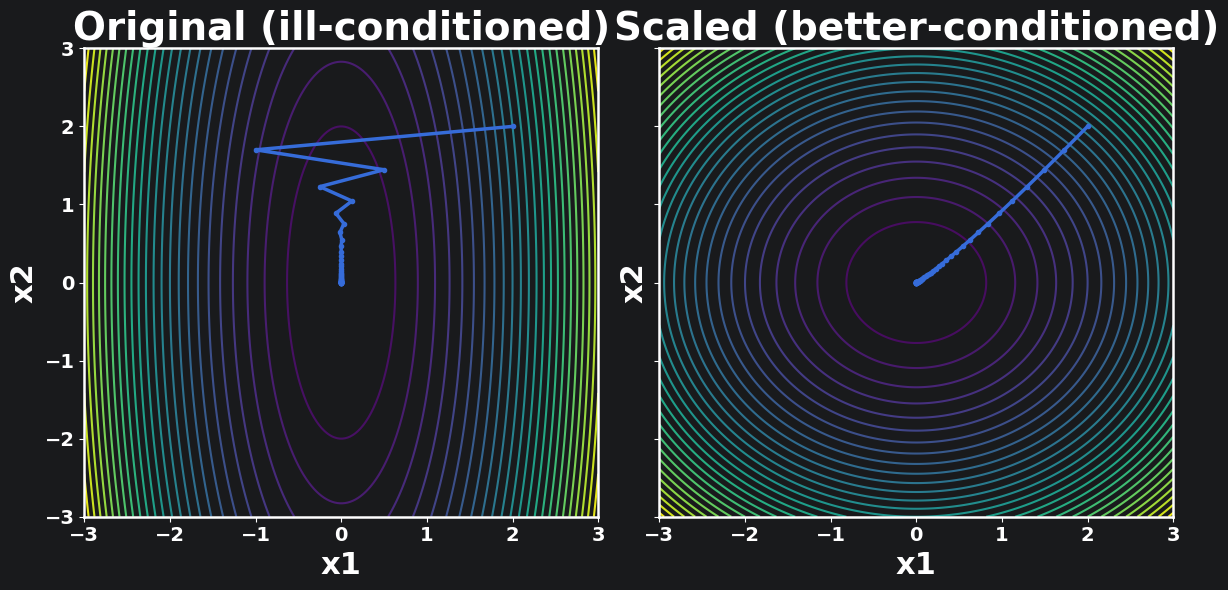

Original κ = 10.0
Scaled κ   = 1.1111111111111112


In [9]:
x0 = torch.tensor([2.0,2.0])
lr = 0.15
steps = 60

fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

for ax, (title, A_mat) in zip(
    axes,
    [("Original (ill-conditioned)", A),
     ("Scaled (better-conditioned)", A_scaled)]
):

    f = quad2d(A_mat)
    xs, losses = run_gd(x0, f, lr=lr, steps=steps)

    X1, X2, Z = contour_plot(A_mat)
    ax.contour(X1, X2, Z, levels=30)

    path = xs.numpy()
    ax.plot(path[:,0], path[:,1], "-o", markersize=3, linewidth=2.5)

    ax.set_title(title, fontsize=28, fontweight="bold")
    ax.set_xlabel("x1", fontsize=22, fontweight="bold")
    ax.set_ylabel("x2", fontsize=22, fontweight="bold")

    style_ax(ax)

plt.tight_layout()
plt.show()
print("Original κ =", np.linalg.eigvals(A).max() / np.linalg.eigvals(A).min())
print("Scaled κ   =", np.linalg.eigvals(A_scaled).max() / np.linalg.eigvals(A_scaled).min())

## 9. When reparameterisation makes things worse

In the previous section we saw that a suitable scaling of the parameters can improve optimisation by reducing the **condition number**

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}.$$

However, reparameterisation is **not automatically beneficial**. If the transformation stretches the wrong directions, it can actually **increase anisotropy** and make optimisation more difficult.

---

### How this can happen

Recall that under a change of variables

$$x = S z,$$

the curvature matrix transforms as

$$A_{\text{new}} = S^\top A S .$$

Depending on the scaling matrix $S$, the eigenvalues of $A_{\text{new}}$ may become **more uneven**, increasing the condition number.

For example, if we scale a steep direction even further, the valley becomes **narrower**, which leads to:
- stronger zig-zag behaviour
- smaller stable learning rates
- slower convergence of gradient descent

In this case, **reparameterisation worsens the optimisation problem rather than improving it**.

---

### Why reparameterisation is tricky in real machine learning problems

In simple quadratic examples we can easily analyse the curvature matrix $A$ and choose a good scaling.

In real machine learning problems, however, this information is **usually not available**.

The loss surface of a neural network is:
- **high-dimensional**
- **nonlinear**
- **often non-convexv

The equivalent of the matrix $A$ (the Hessian of the loss) is extremely large and expensive to compute. As a result:
- we rarely know the true curvature
- we cannot easily find the optimal reparameterisation

Instead, practical optimisation methods attempt to **approximate good scalings automatically**.

Examples include:
- feature normalisation and data preprocessing
- Batch Normalization / Layer Normalization
- adaptive optimisers such as Adam or RMSProp
- preconditioning methods that approximate curvature information

These techniques can be viewed as ways of **implicitly improving the conditioning of the optimisation problem**.

---

### Key insight

Reparameterisation can dramatically change the behaviour of optimisation algorithms, but choosing a good parameterisation requires understanding the **geometry of the loss landscape**.

This is one reason why optimisation in modern machine learning remains challenging:

the geometry of high-dimensional objectives is complex, and good parameterisations are often discovered only through **experience, heuristics, and adaptive algorithms**.

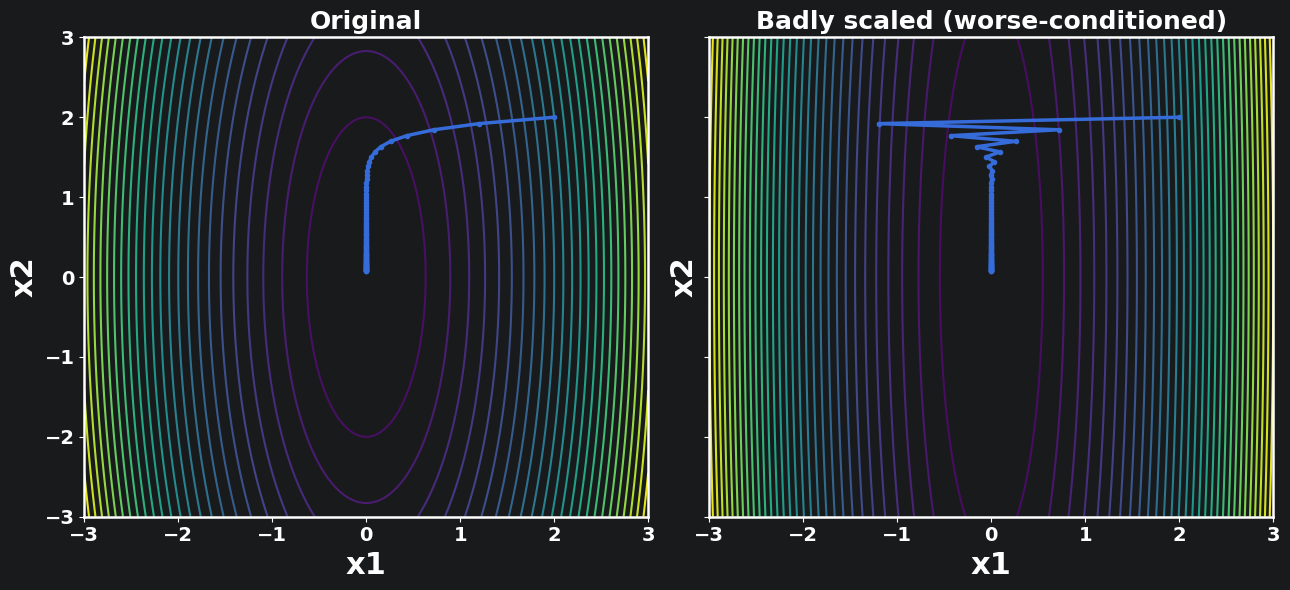

Original matrix:
 [[10.  0.]
 [ 0.  1.]]

Badly scaled matrix:
 [[40.  0.]
 [ 0.  1.]]

Original κ = 10.0
Badly scaled κ = 40.0


In [10]:
A = np.array([
    [10.0, 0.0],
    [0.0, 1.0]
])

# Scale the already-steep x1 direction even more
A_worse = transform_problem(A, scale=2.0)

x0 = torch.tensor([2.0, 2.0])
lr = 0.04
steps = 80

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

for ax, (title, A_mat) in zip(
    axes,
    [
        ("Original", A),
        ("Badly scaled (worse-conditioned)", A_worse),
    ],
):
    f = quad2d(A_mat)
    xs, losses = run_gd(x0, f, lr=lr, steps=steps)

    X1, X2, Z = contour_plot(A_mat, xlim=(-3, 3), ylim=(-3, 3), levels=30)
    ax.contour(X1, X2, Z, levels=30)

    path = xs.numpy()
    ax.plot(path[:, 0], path[:, 1], "-o", markersize=3, linewidth=2.5)

    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("x1", fontsize=22, fontweight="bold")
    ax.set_ylabel("x2", fontsize=22, fontweight="bold")
    style_ax(ax)

plt.tight_layout()
plt.show()

print("Original matrix:\n", A)
print("\nBadly scaled matrix:\n", A_worse)
print()
print("Original κ =", np.linalg.eigvals(A).max() / np.linalg.eigvals(A).min())
print("Badly scaled κ =", np.linalg.eigvals(A_worse).max() / np.linalg.eigvals(A_worse).min())

## 🧭 Closing Remarks

In this tutorial, we moved from analysing **the update rule of gradient descent itself** to analysing **the geometry of the objective on which that rule operates**.

That was the central conceptual shift of the notebook.

The main idea was that optimisation behaviour is not determined by the algorithm alone.
It is also determined by the shape of the loss landscape through which the algorithm moves.

That is why the tutorial focused on simple quadratic objectives.
In that setting, the geometry is clean enough to see directly, but already rich enough to explain many behaviours that later appear in much more complicated optimisation problems.

The isotropic example established the easy case.
When curvature is balanced in all directions, the contours are circular, the gradient points cleanly toward the minimum, and gradient descent follows a direct path.
This gave a useful baseline for comparison.

The ill-conditioned example then showed what changes once curvature becomes uneven.
As soon as one direction becomes much steeper than another, the geometry turns into a narrow valley.
Gradient descent is then pulled strongly across the steep direction while only making slow progress along the shallow one.
This is what produces the familiar zig-zag behaviour.

That led to one of the main lessons of the notebook:

> optimisation can become difficult even for a very simple objective if the geometry is badly conditioned.

The condition number made this idea quantitative.
Rather than describing the landscape only visually, we could measure how imbalanced the curvature was through

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}.$$

This gave a precise way to connect shape to behaviour:

- small $\kappa$ means balanced curvature and easier optimisation,
- large $\kappa$ means anisotropic curvature and harder optimisation.

The convergence-speed experiment then pushed this point further.
It showed that poor conditioning is not only a geometric curiosity.
It directly affects how many steps gradient descent needs, and whether a fixed learning rate remains stable at all.

So another important lesson of the tutorial was:

> conditioning controls not only how optimisation looks, but also how robustly and efficiently gradient descent can operate.

The reparameterisation sections added an especially important perspective.
By changing coordinates, we changed the effective curvature matrix seen by the optimiser.
In one case, the transformation improved conditioning and made the trajectory much more direct.
In another, it worsened conditioning and made the optimisation problem harder.

This showed that optimisation difficulty is not only a property of the objective in the abstract.
It also depends on **how the problem is represented**.

That is a powerful idea, because it connects these simple quadratic examples to real machine learning practice.
Feature scaling, normalisation layers, adaptive methods, and preconditioning strategies can all be viewed as attempts to improve the effective geometry seen by the optimiser.

So across the notebook, several different observations turned out to be expressions of the same underlying principle:

- narrow valleys,
- zig-zag trajectories,
- slow convergence,
- sensitivity to learning rate,
- and the effects of good or bad parameter scaling

all arise from the interaction between the update rule and the geometry of the objective.

This gives the tutorial a clear place in Part 2.

Tutorial 1 showed that gradient descent can be understood as a dynamical system.
This tutorial added the next essential layer:

> the behaviour of that dynamical system depends strongly on the curvature structure of the landscape it is moving through.

So by the end of this notebook, the important outcome is not merely that we have learned the definition of the condition number.
It is that optimisation difficulty should now feel much less mysterious:

- geometry shapes trajectories,
- curvature imbalances create optimisation bottlenecks,
- and representation can either help or hinder convergence.

That gives us the right bridge into the next tutorial.
There, we will begin modifying the optimisation rule itself and study how **momentum** changes the dynamics, especially in the ill-conditioned settings where ordinary gradient descent struggles most.

So the main takeaway of this tutorial is:

> optimisation behaviour is governed not only by the update rule, but by the **interaction between that rule and the geometry of the objective**.